在 Pandas 中，数据相关性是一项重要的分析任务，它帮助我们理解数据中各个变量之间的关系。

Pandas 提供了多种方法来计算和分析数据的相关性，常见的相关性方法包括皮尔逊相关系数（`Pearson`）、斯皮尔曼等级相关系数（`Spearman`）以及肯德尔秩相关系数（`Kendall`）。

以下相关性方法可以帮助我们揭示变量之间的线性关系、非线性关系或单调关系：

***皮尔逊相关系数*** ：衡量变量之间的线性关系，适用于数值型变量。  
***斯皮尔曼等级相关系数*** ：衡量变量之间的单调关系，适用于数值型和顺序型变量。  
***肯德尔秩相关系数*** ：衡量变量之间的秩次关系，适用于小样本数据。  
***相关性矩阵*** ：用来查看各个变量之间的相关性。  
***热图*** ：一种有效的可视化方式，可以帮助我们直观地查看变量之间的相关性。  
什么是相关性？  
相关性表示两个或多个变量之间的关系强度和方向。根据相关性的数值，可以判断变量之间的关系。

正相关：当一个变量增加时，另一个变量也增加。例如，身高和体重之间可能存在正相关关系。  
负相关：当一个变量增加时，另一个变量减少。例如，气温和取暖的使用量之间可能存在负相关关系。  
无相关性：两个变量之间没有明确的关系。  
相关性的数值范围通常在 -1 到 1 之间：  

1：完全正相关  
-1：完全负相关  
0：没有线性相关性  
接近 1 或 -1：表示强相关  
接近 0：表示弱相关  

### 1. Pandas 相关性计算

1. 相关系数(相关性矩阵) `df.corr(methed='pearson', min_periods=1)`

参数说明：

`method` (可选): 字符串类型，用于指定计算相关系数的方法。默认是 `'pearson'` (线性关系强度和方向)，还可以选择 `'kendall'`（Kendall Tau 相关系数）(单调关系，线性和非线性)或 `'spearman'`（Spearman 秩相关系数）(变量秩次关系，小数据集)。

`min_periods` (可选): 表示计算相关系数时所需的最小观测值数量。默认值是 1，即只要有至少一个非空值，就会进行计算。如果指定了 min_periods，并且在某些列中的非空值数量小于该值，则相应列的相关系数将被设为 NaN。

df.corr() 方法返回一个相关系数矩阵，矩阵的行和列对应数据框的列名，矩阵的元素是对应列之间的相关系数。

常见的相关性系数包括 Pearson 相关系数和 Spearman 秩相关系数

2. 协方差矩阵 `df.cov()`

In [9]:
import pandas as pd
import numpy as np

# 设置随机种子，保证结果可复现
np.random.seed(42)

# 构造DataFrame
df = pd.DataFrame({
    'x': np.arange(1, 11),  # x: 1,2,...,10（数值型变量）
    'y1': np.square(np.arange(1, 11)),  # y1 = x²（非线性但单调递增）
    'y2': np.arange(1, 11) + np.random.randint(-2, 3, size=10),  # x加随机噪声（弱线性）
    'y3': 20 - np.arange(1, 11)  # y3 = 20 - x（线性负相关）
})
display(df)

# pearson相关系数
correlation = df.corr(method='pearson')
display(correlation)

# spearman相关系数
spearman_correlation = df.corr(method='spearman')
display(spearman_correlation)

# kendall相关系数
kendall_correlation = df.corr(method='kendall')
display(kendall_correlation)

,x,y1,y2,y3
0,1,1,2,19
1,2,4,4,18
2,3,9,3,17
3,4,16,6,16
4,5,25,7,15
5,6,36,5,14
6,7,49,7,13
7,8,64,8,12
8,9,81,9,11
9,10,100,12,10


,x,y1,y2,y3
x,1.000000,0.974559,0.928760,-1.000000
y1,0.974559,1.000000,0.931288,-0.974559
y2,0.928760,0.931288,1.000000,-0.928760
y3,-1.000000,-0.974559,-0.928760,1.000000


,x,y1,y2,y3
x,1.000000,1.000000,0.942254,-1.000000
y1,1.000000,1.000000,0.942254,-1.000000
y2,0.942254,0.942254,1.000000,-0.942254
y3,-1.000000,-1.000000,-0.942254,1.000000


,x,y1,y2,y3
x,1.000000,1.000000,0.853986,-1.000000
y1,1.000000,1.000000,0.853986,-1.000000
y2,0.853986,0.853986,1.000000,-0.853986
y3,-1.000000,-1.000000,-0.853986,1.000000


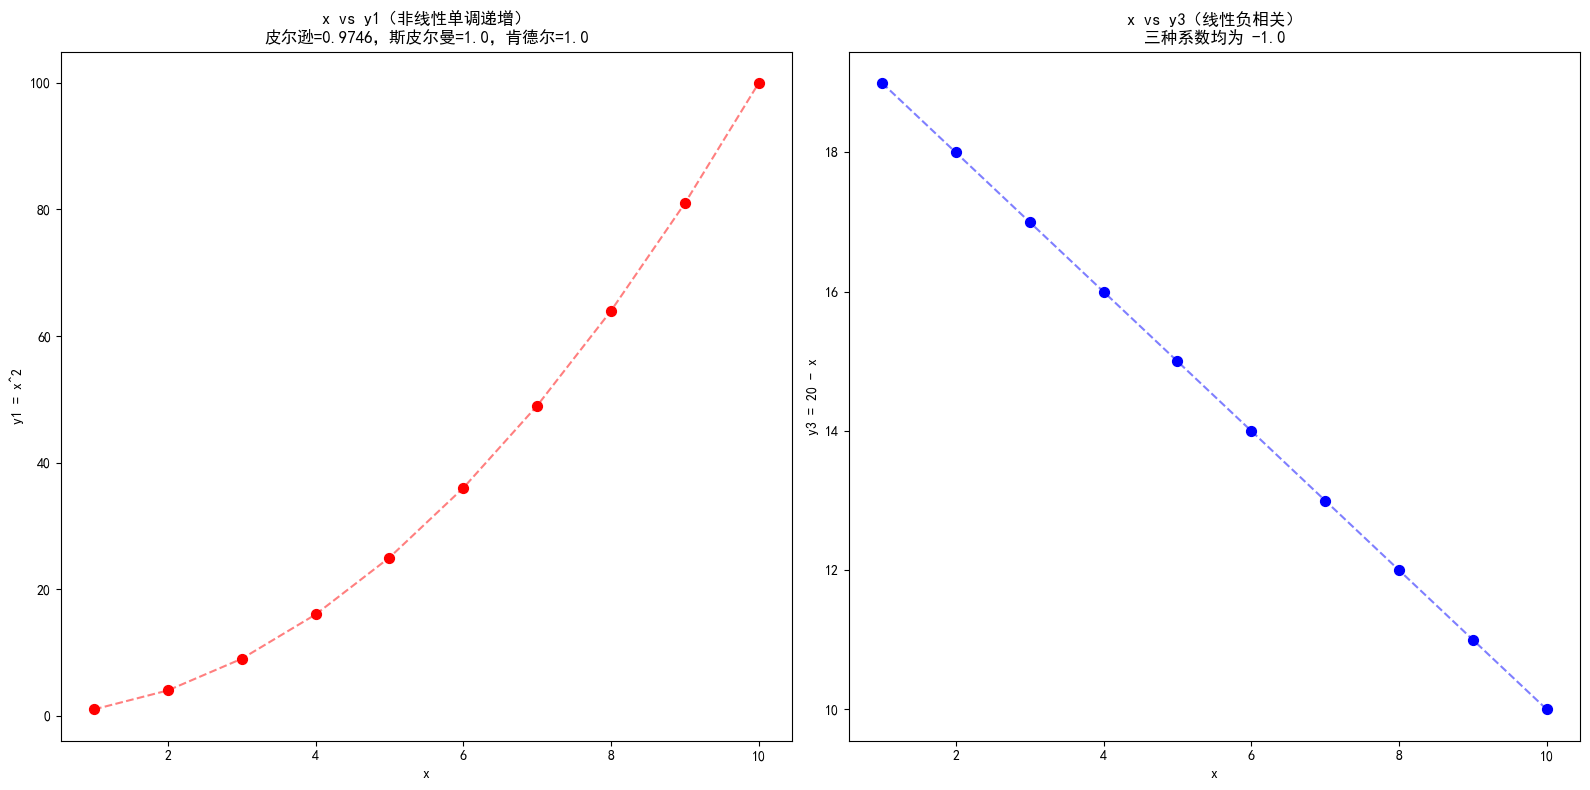

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 左图：x vs y1（非线性但单调递增）
ax1.scatter(df['x'], df['y1'], color='red', s=50)
ax1.plot(df['x'], df['y1'], color='red', linestyle='--', alpha=0.5)
ax1.set_title('x vs y1（非线性单调递增）\n皮尔逊=0.9746，斯皮尔曼=1.0，肯德尔=1.0')
ax1.set_xlabel('x')
ax1.set_ylabel('y1 = x^2')

# 右图：x vs y3（线性负相关）
ax2.scatter(df['x'], df['y3'], color='blue', s=50)
ax2.plot(df['x'], df['y3'], color='blue', linestyle='--', alpha=0.5)
ax2.set_title('x vs y3（线性负相关）\n三种系数均为 -1.0')
ax2.set_xlabel('x')
ax2.set_ylabel('y3 = 20 - x')

plt.tight_layout()
plt.show()

### 2. 相关型热图 (Correlation Heatmap)

`sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)`

说明：

sns.heatmap() 绘制相关性热图，

`annot=True` 表示在热图上显示数值，

`cmap='coolwarm'` 设置颜色范围，

`vmin=-1, vmax=1` 限制颜色范围为 -1 到 1。

相关性分析中的应用

1、特征选择  
在机器学习建模中，相关性分析常常用于特征选择。通过分析不同特征之间的相关性，可以帮助我们选择与目标变量最相关的特征，并去除与其他特征高度相关的冗余特征，从而提高模型的表现和效率。

2、处理多重共线性  
如果两个或多个特征之间的相关性非常高（接近 1 或 -1），那么这些特征之间存在多重共线性问题。在回归分析中，多重共线性会导致模型的不稳定性和预测不准确。可以通过删除或合并相关性较高的特征来解决多重共线性问题。


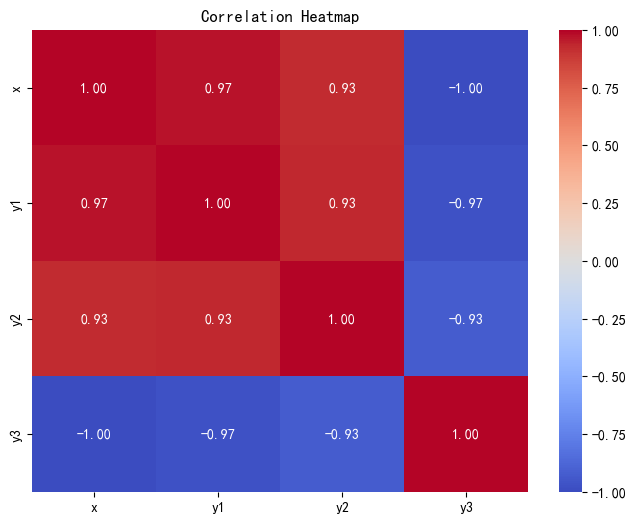

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 绘制相关性热图
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()